In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn import tree

import seaborn as sns

import pickle

In [2]:
df=pd.read_csv(r"C:\Users\HP\Downloads\archive (17)\car_price.csv")

In [3]:
print(df)

                      CarName      carbody drivewheel enginelocation fueltype  \
0          alfa-romero giulia  convertible        rwd          front      gas   
1         alfa-romero stelvio  convertible        rwd          front      gas   
2    alfa-romero Quadrifoglio    hatchback        rwd          front      gas   
3                 audi 100 ls        sedan        fwd          front      gas   
4                  audi 100ls        sedan        4wd          front      gas   
..                        ...          ...        ...            ...      ...   
205                    bmw x3        sedan        rwd          front      gas   
206             mitsubishi g4    hatchback        fwd          front      gas   
207               peugeot 304        sedan        rwd          front   diesel   
208          peugeot 504 (sw)        wagon        rwd          front      gas   
209               peugeot 504        wagon        rwd          front   diesel   

    aspiration doornumber c

In [4]:
##Data cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CarName           210 non-null    object 
 1   carbody           210 non-null    object 
 2   drivewheel        210 non-null    object 
 3   enginelocation    210 non-null    object 
 4   fueltype          210 non-null    object 
 5   aspiration        210 non-null    object 
 6   doornumber        210 non-null    object 
 7   cylindernumber    210 non-null    object 
 8   enginetype        210 non-null    object 
 9   fuelsystem        210 non-null    object 
 10  symboling         210 non-null    int64  
 11  wheelbase         210 non-null    float64
 12  carlength         210 non-null    float64
 13  carwidth          210 non-null    float64
 14  carheight         210 non-null    float64
 15  curbweight        210 non-null    int64  
 16  enginesize        210 non-null    int64  
 1

In [5]:
df.describe()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,0.828571,98.947143,174.354286,65.935714,53.768571,2565.909524,127.266667,3.333905,3.258286,10.224381,104.000000,5110.476190,25.180952,30.695238,13289.665081
std,1.244757,6.172319,12.457557,2.141794,2.489242,522.279331,41.297095,0.270150,0.311277,4.068746,39.114725,484.530811,6.487059,6.835908,7918.471818
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.800000,64.125000,52.000000,2174.250000,98.000000,3.150000,3.110000,8.525000,70.000000,4800.000000,19.000000,25.000000,7823.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2422.500000,120.000000,3.320000,3.290000,9.000000,95.000000,5100.000000,24.000000,30.000000,10470.000000
75%,2.000000,102.400000,183.500000,66.900000,55.575000,2953.500000,145.750000,3.587500,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16502.250000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [6]:
df.isnull().sum()

CarName             0
carbody             0
drivewheel          0
enginelocation      0
fueltype            0
aspiration          0
doornumber          0
cylindernumber      0
enginetype          0
fuelsystem          0
symboling           0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginesize          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [8]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
205     True
206     True
207     True
208     True
209     True
Length: 210, dtype: bool

In [9]:
X = df[['carlength',
        'carheight',
        'carwidth',
        'curbweight',
        'enginesize',
        'stroke',
        'boreratio',
        'horsepower']]

Y = df['price']

In [10]:
print(X)
print(Y)

     carlength  carheight  carwidth  curbweight  enginesize  stroke  \
0        168.8       48.8      64.1        2548         130    2.68   
1        168.8       48.8      64.1        2548         130    2.68   
2        171.2       52.4      65.5        2823         152    3.47   
3        176.6       54.3      66.2        2337         109    3.40   
4        176.6       54.3      66.4        2824         136    3.40   
..         ...        ...       ...         ...         ...     ...   
205      176.8       54.3      64.8        2765         164    3.19   
206      173.0       49.4      65.4        2328         122    3.46   
207      186.7       56.7      68.4        3197         152    3.52   
208      198.9       58.7      68.4        3230         120    3.19   
209      198.9       58.7      68.4        3430         152    3.52   

     boreratio  horsepower  
0         3.47         111  
1         3.47         111  
2         2.68         154  
3         3.19         102  
4 

In [11]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [12]:
Reg=DecisionTreeRegressor()

In [13]:
Reg.fit(X_train,Y_train)

DecisionTreeRegressor()

In [14]:
Reg.predict(X_test)

array([ 5399. , 17450. , 14869. , 18420. , 10245. , 15580. ,  6575. ,
        7995. , 14869. , 12940. , 18620. ,  9995. , 17425. , 34028. ,
       36880. , 45400. ,  7898. ,  5974.5,  8449. ,  7999. , 18620. ,
       11845. ,  8013. , 12440. , 17425. ,  7126. ,  7609. , 12964. ,
       36880. , 10898. , 10795. , 28248. , 13499. , 28248. , 18399. ,
       12170. , 15998. ,  7999. , 12764. ,  7898. , 13415. ,  8358. ])

In [15]:
print(Reg)

DecisionTreeRegressor()


In [16]:
Reg.score(X_train,Y_train)

0.9983715277717804

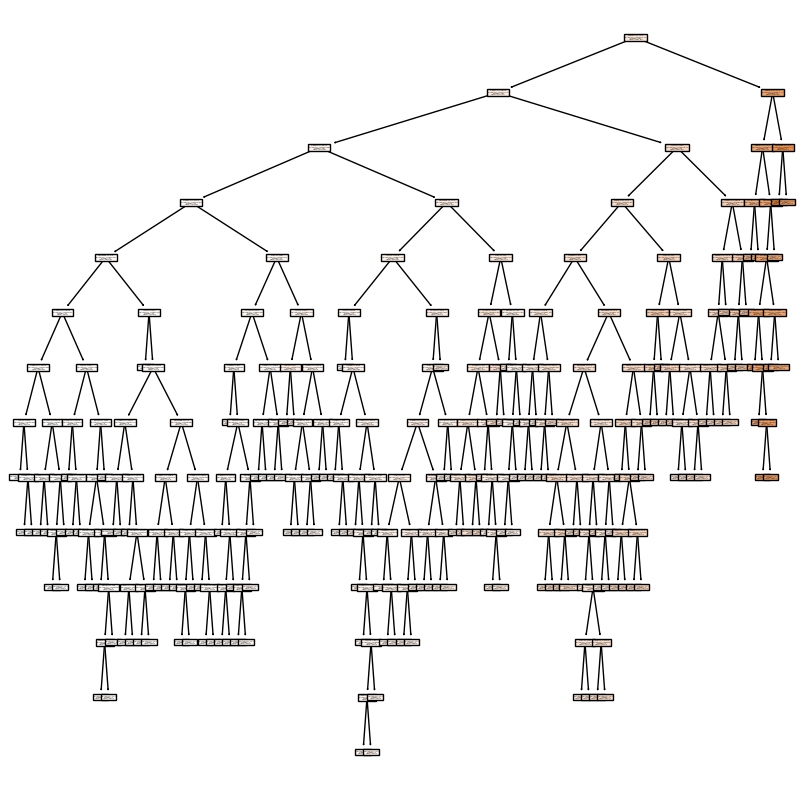

In [17]:
plt.figure(figsize=(10,10))
tree.plot_tree(
    Reg,
    filled=True,
    feature_names=X.columns)
plt.show()

In [20]:
with open("Car_price.pkl", "wb") as file:
    pickle.dump(Reg, file)
print("Model saved successfully")

Model saved successfully


In [21]:
!pip install customtkinter
import customtkinter as ctk

In [ ]:
from tkinter import *
import pickle
import numpy as np

# ------------------ Load Model ------------------
model = pickle.load(open("Car_price.pkl", "rb"))

# ------------------ Prediction Function ------------------
def predict_price():
    try:
        data = np.array([[
            float(entry_length.get()),
            float(entry_height.get()),
            float(entry_width.get()),
            float(entry_curbweight.get()),
            float(entry_enginesize.get()),
            float(entry_stroke.get()),
            float(entry_boreratio.get()),
            float(entry_horsepower.get())
        ]])

        prediction = model.predict(data)

        output.config(
            text=f"Predicted Car Price:\n₹ {prediction[0]:,.2f}",
            fg="green"
        )

    except ValueError:
        output.config(
            text="Please enter valid numeric values!",
            fg="red"
        )

# ------------------ GUI ------------------
root = Tk()
root.title("Car Price Prediction System")
root.geometry("700x700")
root.configure(bg="#8B0000")

heading = Label(
    root,
    text="Car Price Prediction System",
    font=("Arial", 22, "bold"),
    bg="#8B0000",
    fg="white"
)
heading.pack(pady=20)

# Car Length
Label(root, text="Car Length", bg="#8B0000", fg="white", font=("Arial",12)).pack()
entry_length = Entry(root, width=30, font=("Arial",12))
entry_length.pack(pady=5)

# Car Height
Label(root, text="Car Height", bg="#8B0000", fg="white", font=("Arial",12)).pack()
entry_height = Entry(root, width=30, font=("Arial",12))
entry_height.pack(pady=5)

# Car Width
Label(root, text="Car Width", bg="#8B0000", fg="white", font=("Arial",12)).pack()
entry_width = Entry(root, width=30, font=("Arial",12))
entry_width.pack(pady=5)

# Curb Weight
Label(root, text="Curb Weight", bg="#8B0000", fg="white", font=("Arial",12)).pack()
entry_curbweight = Entry(root, width=30, font=("Arial",12))
entry_curbweight.pack(pady=5)

# Engine Size
Label(root, text="Engine Size", bg="#8B0000", fg="white", font=("Arial",12)).pack()
entry_enginesize = Entry(root, width=30, font=("Arial",12))
entry_enginesize.pack(pady=5)

# Stroke
Label(root, text="Stroke", bg="#8B0000", fg="white", font=("Arial",12)).pack()
entry_stroke = Entry(root, width=30, font=("Arial",12))
entry_stroke.pack(pady=5)

# Bore Ratio
Label(root, text="Bore Ratio", bg="#8B0000", fg="white", font=("Arial",12)).pack()
entry_boreratio = Entry(root, width=30, font=("Arial",12))
entry_boreratio.pack(pady=5)

# Horsepower
Label(root, text="Horsepower", bg="#8B0000", fg="white", font=("Arial",12)).pack()
entry_horsepower = Entry(root, width=30, font=("Arial",12))
entry_horsepower.pack(pady=5)

# Predict Button
Button(
    root,
    text="Predict Price",
    command=predict_price,
    bg="#DC143C",
    fg="white",
    font=("Arial",14,"bold"),
    padx=20,
    pady=8
).pack(pady=20)

# Output Label
output = Label(
    root,
    text="Predicted Price:",
    bg="#FFE4E1",
    fg="black",
    font=("Arial",14,"bold"),
    width=35,
    height=2
)
output.pack(pady=20)

root.mainloop()

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
